In [5]:
!pip install tensorflow==2.9.1
import tensorflow as tf
print(tf.__version__)

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 511.7/511.7 MB 2.4 MB/s eta 0:00:0000:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.1/1.1 MB 53.9 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 5.8/5.8 MB 79.4 MB/s eta 0:00:00:00:0100:01
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.6/1.6 MB 67.5 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 438.7/438.7 kB 35.6 MB/s eta 0:00:00
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 42.6/42.6 kB 4.6 MB/s eta 0:00:00
  Attempting uninstall: keras
    Found existing installation: keras 2.11.0
    Uninstalling keras-2.11.0:
      Successfully uninstalled keras-2.11.0
  Attempting uninstall: flatbuffers
    Found existing installation: flatbuffers 23.1.21
    Uninstalling flatbuffers-23.1.21:
      Successfully uninstalled flatbuffers-23.1.21
  Attempting uninstall: tensorflow-estimator
    Found existing installation: tensorflow-estimator 2.11.0
    Uninstalling tensorflow-estimator-2.11.0:
      Successfully 

In [6]:
from numpy.random import seed
seed(101)
import tensorflow
tensorflow.random.set_seed(101)
import pandas as pd
import numpy as np
import tensorflow
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.metrics import categorical_crossentropy
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.models import Model
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, ModelCheckpoint
import os
from sklearn.metrics import confusion_matrix
from sklearn.model_selection import train_test_split
import numpy as np
import cv2
import random
import matplotlib.pyplot as plt
from tqdm import tqdm
from sklearn.utils import shuffle
import tensorflow as tf
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import ResNet50
from tensorflow.keras.applications.resnet50 import preprocess_input
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
import itertools
import shutil

import os
import matplotlib.pyplot as plt
%matplotlib inline

In [7]:
base_dir = r'collect_data_test'
os.mkdir(base_dir)
acne = r'/kaggle/working/collect_data_test/1'
os.mkdir(acne)
Eczema= r'/kaggle/working/collect_data_test/2'
os.mkdir(Eczema)
Exanthems = r'/kaggle/working/collect_data_test/3'
os.mkdir(Exanthems)
Scabies = r'/kaggle/working/collect_data_test/4'
os.mkdir(Scabies)
Tinea = r'/kaggle/working/collect_data_test/5'
os.mkdir(Tinea)
Vasculitis = r'/kaggle/working/collect_data_test/6'
os.mkdir(Vasculitis)


In [ ]:
import os
import cv2

def copy_images(input_folder, output_folder):
    if not os.path.exists(output_folder):
        os.makedirs(output_folder)
    
    file_list = os.listdir(input_folder)
    input_file_paths = [os.path.join(input_folder, file_name) for file_name in file_list]
    output_file_paths = [os.path.join(output_folder, file_name) for file_name in file_list]

    for input_path, output_path in zip(input_file_paths, output_file_paths):
        img = cv2.imread(input_path)
        img=cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        # Resize the image to a specific size
        img = cv2.resize(img, (224, 224))
        cv2.imwrite(output_path, img)

# Define input and output folder paths
folders = [
    ('/kaggle/input/balance-skin-data/test/Acne and Rosacea Photos', '/kaggle/working/collect_data_test/1'),
    ('/kaggle/input/balance-skin-data/test/Eczema Photos', '/kaggle/working/collect_data_test/2'),
    ('/kaggle/input/balance-skin-data/test/Exanthems and Drug Eruptions', '/kaggle/working/collect_data_test/3'),
    ('/kaggle/input/balance-skin-data/test/Scabies Lyme Disease and other Infestations and Bites', '/kaggle/working/collect_data_test/4'),
    ('/kaggle/input/dermnet/test/Tinea Ringworm Candidiasis and other Fungal Infections', '/kaggle/working/collect_data_test/5'),
    ('/kaggle/input/balance-skin-data/test/Vasculitis Photos', '/kaggle/working/collect_data_test/6')
]

# Copy images from each folder
for input_folder, output_folder in folders:
    copy_images(input_folder, output_folder)


In [9]:
labels = ['1','2','3','4','5','6']
X_test = []
y_test = []
image_size = 224
for i in labels:
    folderPath = os.path.join('/kaggle/working/collect_data_test',i)
    for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size, image_size))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        X_test.append(img)
        y_test.append(i)

X_test = np.array(X_test)
y_test = np.array(y_test)

100%|██████████| 105/105 [00:00<00:00, 174.48it/s]


In [10]:
# Create a new directory
base_dir = r'collect_data'
os.mkdir(base_dir)
acne = r'/kaggle/working/collect_data/1'
os.mkdir(acne)
Eczema= r'/kaggle/working/collect_data/2'
os.mkdir(Eczema)
Exanthems = r'/kaggle/working/collect_data/3'
os.mkdir(Exanthems)
Scabies = r'/kaggle/working/collect_data/4'
os.mkdir(Scabies)
Tinea = r'/kaggle/working/collect_data/5'
os.mkdir(Tinea)
Vasculitis = r'/kaggle/working/collect_data/6'
os.mkdir(Vasculitis)

In [11]:
class_names=['Acne and Rosacea Photos','Eczema Photos','Exanthems and Drug Eruptions','Scabies Lyme Disease and other Infestations and Bites','Tinea Ringworm Candidiasis and other Fungal Infections','Vasculitis Photos']

Count of images in /kaggle/input/balance-skin-data/train/Acne and Rosacea Photos before augmentation: 540
Count of images in /kaggle/input/balance-skin-data/train/Eczema Photos before augmentation: 511
Count of images in /kaggle/input/balance-skin-data/train/Exanthems and Drug Eruptions before augmentation: 402
Count of images in /kaggle/input/balance-skin-data/train/Scabies Lyme Disease and other Infestations and Bites before augmentation: 388
Count of images in /kaggle/input/dermnet/train/Tinea Ringworm Candidiasis and other Fungal Infections before augmentation: 1300
Count of images in /kaggle/input/balance-skin-data/train/Vasculitis Photos before augmentation: 415
Count of images in /kaggle/working/collect_data/1 after augmentation: 3780
Count of images in /kaggle/working/collect_data/2 after augmentation: 3577
Count of images in /kaggle/working/collect_data/3 after augmentation: 3618
Count of images in /kaggle/working/collect_data/4 after augmentation: 3492
Count of images in /kag

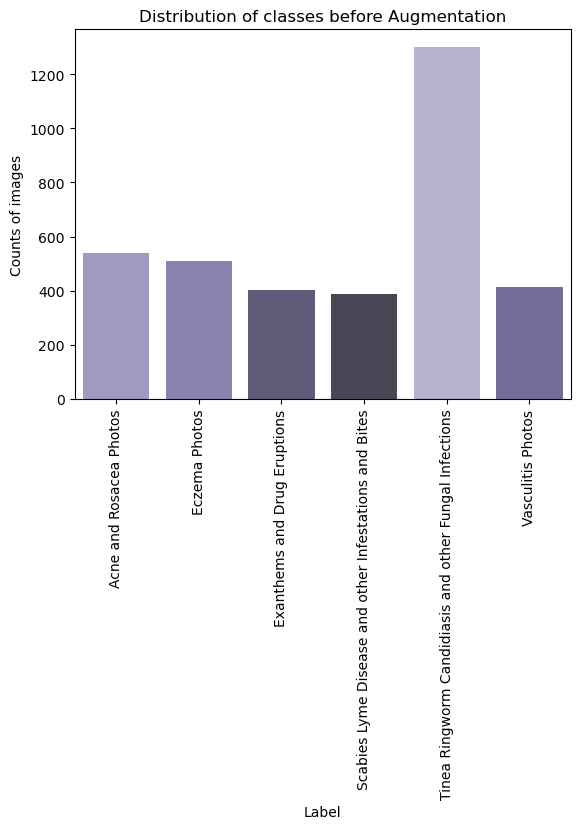

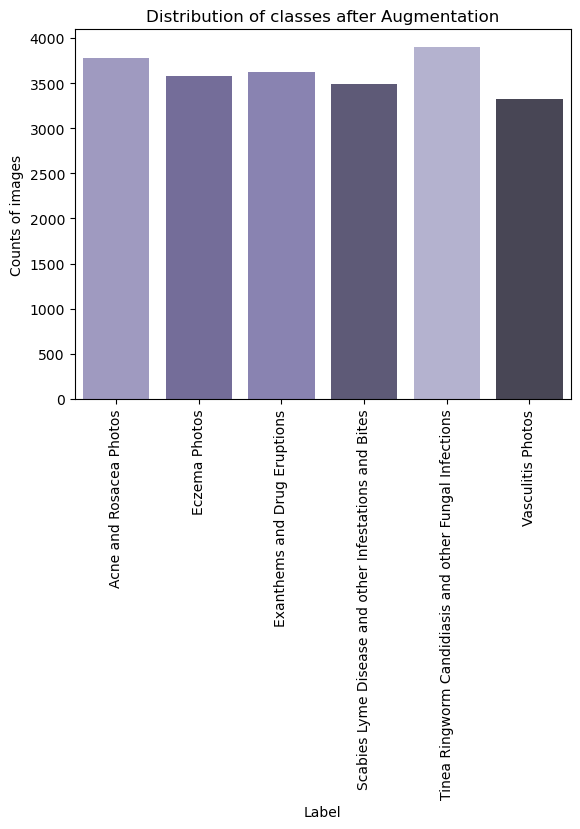

In [12]:
import os
import numpy as np
import pandas as pd
from skimage import io
from matplotlib import pyplot as plt
import seaborn as sns
from keras.preprocessing.image import ImageDataGenerator

# Function to count images in each folder
def count_images(directory):
    return len([name for name in os.listdir(directory) if os.path.isfile(os.path.join(directory, name))])

# Function to create a data dictionary
def data_dictionary(path_train):
    train_data_categories = os.listdir(path_train)
    list_train = train_data_categories
    train_dictionary = {"image_path": [], "target": [], "Label": [], "Image": []}
    k = 0
    for i in list_train:
        path_train_item = os.path.join(path_train, i)
        image_list_train = os.listdir(path_train_item)
        for j in image_list_train:
            img_path_train = os.path.join(path_train_item, j)
            train_dictionary["image_path"].append(img_path_train)
            train_dictionary['target'].append(k)
            train_dictionary['Label'].append(i)
            train_dictionary['Image'].append(io.imread(img_path_train))
        k += 1
    return pd.DataFrame(train_dictionary)

# Function to augment images
def augment_images(input_directory, output_directory, augmentation_factor):
    # Ensure the output directory exists
    if not os.path.exists(output_directory):
        os.makedirs(output_directory)
    
    # Initialize the ImageDataGenerator with desired augmentations
    datagen = ImageDataGenerator(
        zoom_range=0.1,
        width_shift_range=0.1,
        height_shift_range=0.1,
        horizontal_flip=True,
        vertical_flip=True,
    )
    
    # Load and augment the original images
    image_files = os.listdir(input_directory)
    
    def load_and_preprocess_image(image_path):
        # Load the image from the specified path
        img = io.imread(image_path)
        # Resize the image to a specific size
        img = cv2.resize(img, (224, 224))  # Replace target_width and target_height
        return img
    
    for image_file in image_files:
        image_path = os.path.join(input_directory, image_file)
        img = load_and_preprocess_image(image_path)  # Load and preprocess your image as needed
        # Reshape to (1, height, width, channels) for the generator
        img = img.reshape((1,) + img.shape)
        i = 0
        for batch in datagen.flow(img, batch_size=1):
            augmented_image = batch[0].astype('uint8')
            augmented_filename = f"{os.path.splitext(image_file)[0]}_augmented_{i}.jpg"
            augmented_image_path = os.path.join(output_directory, augmented_filename)
            io.imsave(augmented_image_path, augmented_image)
            i += 1
            if i >= augmentation_factor:
                break

# Define directories
input_folder_paths = [
    '/kaggle/input/balance-skin-data/train/Acne and Rosacea Photos',
    '/kaggle/input/balance-skin-data/train/Eczema Photos',
    '/kaggle/input/balance-skin-data/train/Exanthems and Drug Eruptions',
    '/kaggle/input/balance-skin-data/train/Scabies Lyme Disease and other Infestations and Bites',
    '/kaggle/input/dermnet/train/Tinea Ringworm Candidiasis and other Fungal Infections',
    '/kaggle/input/balance-skin-data/train/Vasculitis Photos'
]

output_folder_paths = [
    '/kaggle/working/collect_data/1',
    '/kaggle/working/collect_data/2',
    '/kaggle/working/collect_data/3',
    '/kaggle/working/collect_data/4',
    '/kaggle/working/collect_data/5',
    '/kaggle/working/collect_data/6'
]

augmentation_factors = [7, 7, 9, 9, 3, 8]

# Print counts before augmentation
counts_before = []
for input_folder in input_folder_paths:
    count_before = count_images(input_folder)
    counts_before.append(count_before)
    print(f'Count of images in {input_folder} before augmentation: {count_before}')

# Perform augmentation
for input_folder, output_folder, augmentation_factor in zip(input_folder_paths, output_folder_paths, augmentation_factors):
    augment_images(input_folder, output_folder, augmentation_factor)

# Print counts after augmentation
counts_after = []
for output_folder in output_folder_paths:
    count_after = count_images(output_folder)
    counts_after.append(count_after)
    print(f'Count of images in {output_folder} after augmentation: {count_after}')

# Create dataframes for plotting
labels = ['Acne and Rosacea Photos', 'Eczema Photos', 'Exanthems and Drug Eruptions', 
          'Scabies Lyme Disease and other Infestations and Bites', 
          'Tinea Ringworm Candidiasis and other Fungal Infections', 'Vasculitis Photos']

df_before = pd.DataFrame({'Label': labels, 'Counts': counts_before})
df_after = pd.DataFrame({'Label': labels, 'Counts': counts_after})

# Function to create bar plot
def create_bar_plot_with_counts(df, title):
    pal = sns.color_palette("Purples_d", len(df))
    rank = df['Counts'].argsort().argsort()
    sns.barplot(x='Label', y='Counts', data=df, palette=np.array(pal[::-1])[rank])
    plt.title(title)
    plt.ylabel("Counts of images")
    plt.xticks(rotation=90)
    plt.show()

# Plot counts before augmentation
create_bar_plot_with_counts(df_before, "Distribution of classes before Augmentation")

# Plot counts after augmentation
create_bar_plot_with_counts(df_after, "Distribution of classes after Augmentation")


In [13]:
labels = ['1','2','3','4','5','6']


In [14]:
X_train = []
y_train = []
image_size = 224
for i in labels:
    folderPath = os.path.join('/kaggle/working/collect_data',i)
    for j in tqdm(os.listdir(folderPath)):
        img = cv2.imread(os.path.join(folderPath,j))
        img = cv2.resize(img,(image_size, image_size))
        img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
        X_train.append(img)
        y_train.append(i)

X_train = np.array(X_train)
y_train = np.array(y_train)

100%|██████████| 3320/3320 [00:02<00:00, 1243.14it/s]


ValueError: The truth value of an array with more than one element is ambiguous. Use a.any() or a.all()

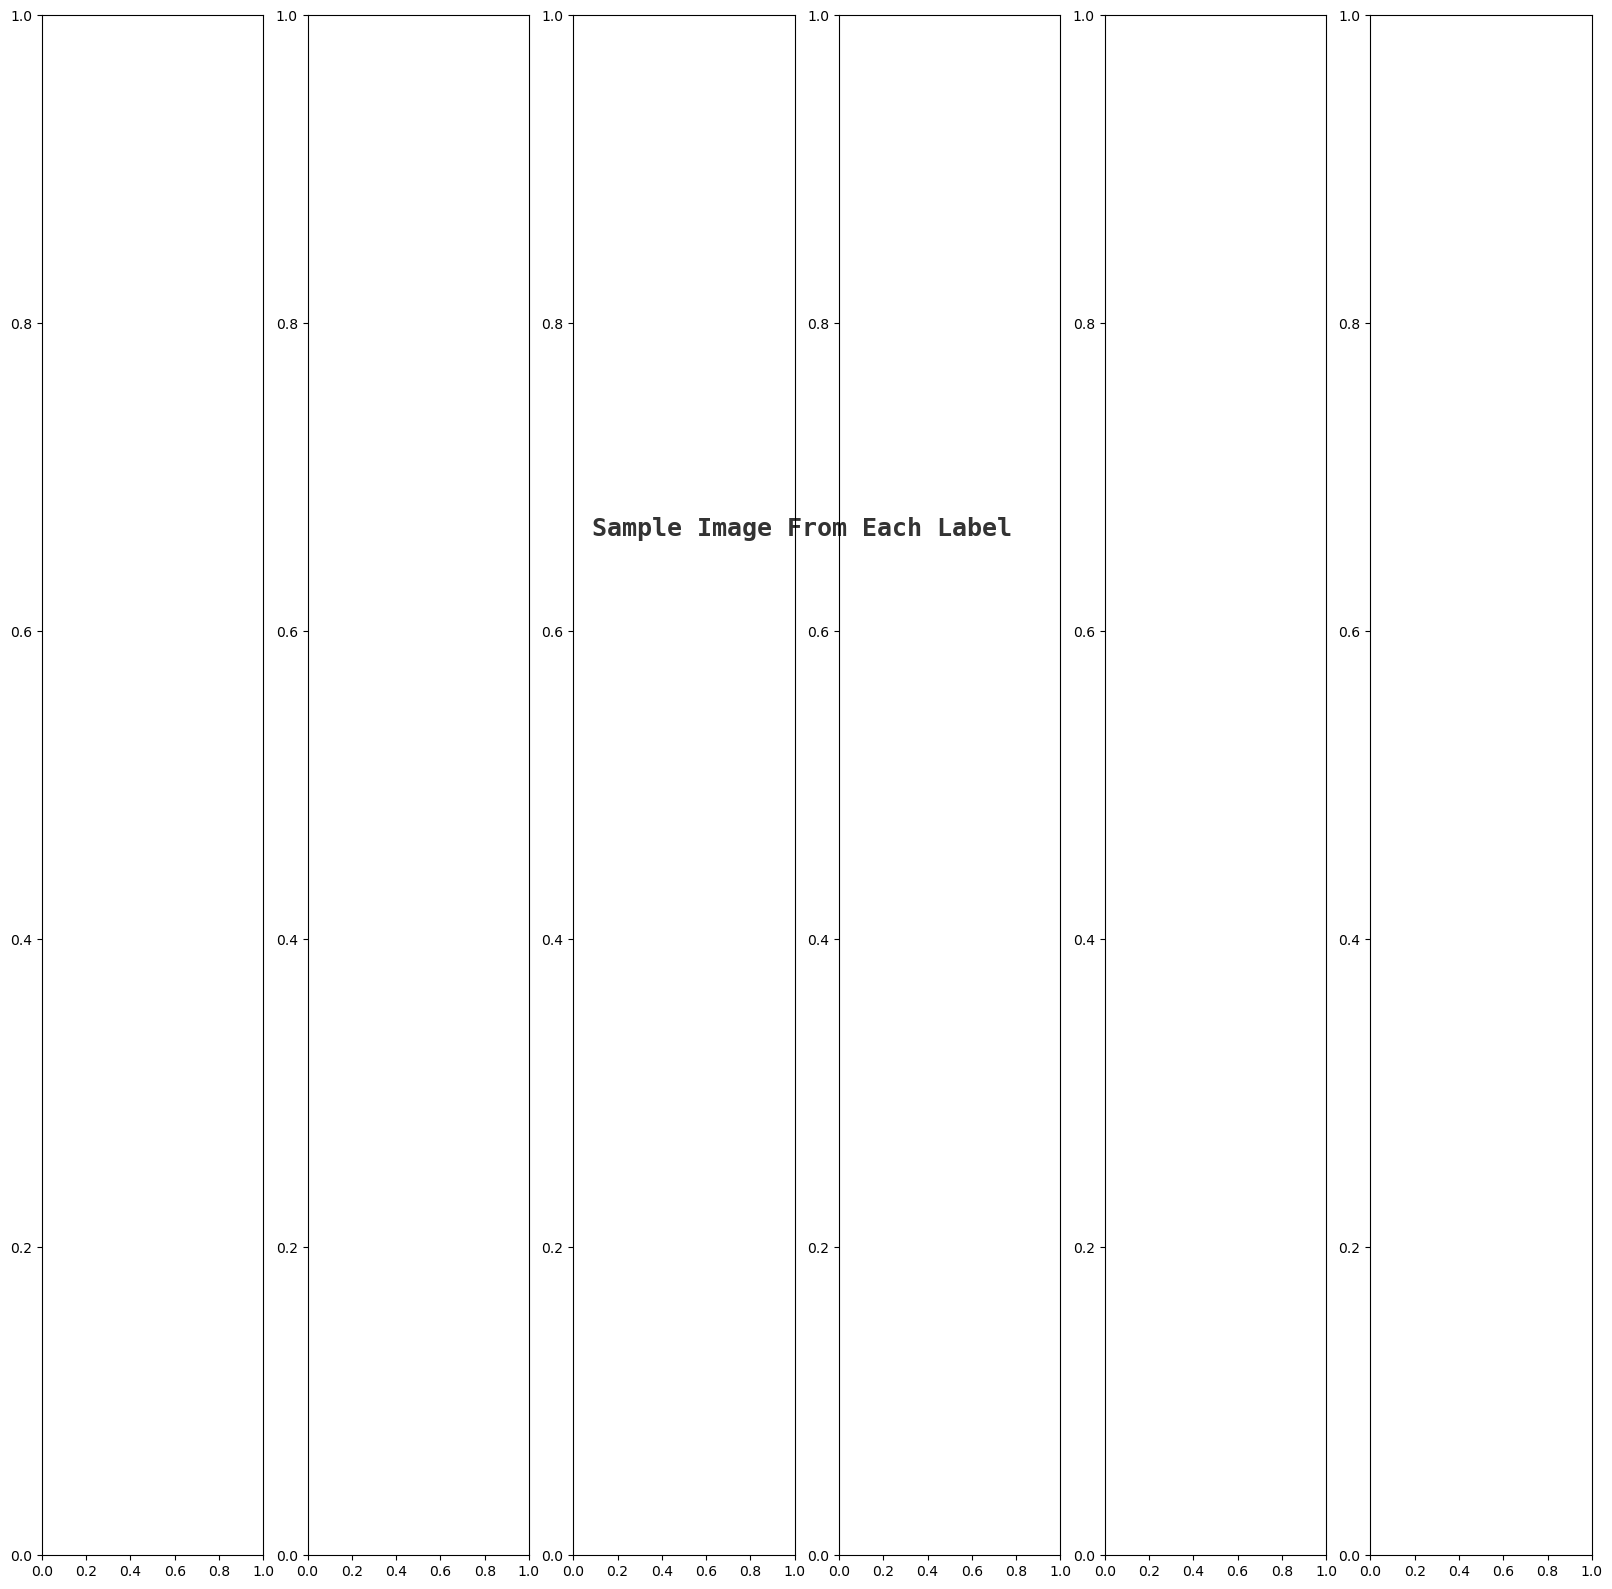

In [83]:
import random
import matplotlib.pyplot as plt

k = 0
fig, ax = plt.subplots(1, 6, figsize=(20, 20))
fig.text(s='Sample Image From Each Label', size=18, fontweight='bold',
         fontname='monospace', y=0.62, x=0.4, alpha=0.8)

for i in range(len(labels)):
    label_indices = [j for j in range(len(y_train)) if y_train[j] == int(labels[i])]
    random_index = random.choice(label_indices)
    
    ax[k].imshow(X_train[random_index])
    ax[k].set_title(class_names[i])
    ax[k].axis('off')
    k += 1

plt.show()


In [17]:
from sklearn.model_selection import train_test_split
X_train, y_train = shuffle(X_train,y_train, random_state=101)
X_train,X_val,y_train,y_val = train_test_split(X_train,y_train, test_size=0.2,random_state=101)


In [18]:
y_train_new = []
for i in y_train:
    y_train_new.append(labels.index(i))
y_train = y_train_new
y_train = tf.keras.utils.to_categorical(y_train)

y_val_new = []
for i in y_val:
    y_val_new.append(labels.index(i))
y_val = y_val_new
y_val = tf.keras.utils.to_categorical(y_val)

y_test_new = []
for i in y_test:
    y_test_new.append(labels.index(i))
y_test = y_test_new
y_test = tf.keras.utils.to_categorical(y_test)

In [19]:
print('shape of x_train:',X_train.shape)
print('shape of x_train:',X_val.shape)
print('shape of x_train:',X_test.shape)
print('shape of x_train:',y_train.shape)
print('shape of x_train:',y_val.shape)
print('shape of x_train:',y_test.shape)

shape of x_train: (17349, 224, 224, 3)
shape of x_train: (4338, 224, 224, 3)
shape of x_train: (1215, 224, 224, 3)
shape of x_train: (17349, 6)
shape of x_train: (4338, 6)
shape of x_train: (1215, 6)


In [81]:
print('shape of x_train:',X_train.shape)
print('shape of x_val:',X_val.shape)

print('shape of y_train:',y_train.shape)
print('shape of y_val:',y_val.shape)


shape of x_train: (17349, 224, 224, 3)
shape of x_val: (4338, 224, 224, 3)
shape of y_train: (17349, 6)
shape of y_val: (4338, 6)


# resnet

In [20]:
base_model = ResNet50(weights='imagenet', include_top=False, input_shape=(224, 224, 3))


94765736/94765736 [==============================] - 1s 0us/step


In [21]:
base_model.trainable = False


In [22]:
num_classes = 6
x = GlobalAveragePooling2D()(base_model.output)
x = Dense(512, activation='relu')(x)
x = tf.keras.layers.Dropout(rate=0.5)(x)
predictions = Dense(6, activation='softmax')(x)

In [23]:
model = Model(inputs=base_model.input, outputs=predictions)
optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

In [24]:
EPOCHS = 65
BATCH_SIZE = 32
best_model_dir = '/kaggle/working/'

os.makedirs(best_model_dir, exist_ok=True)

model_checkpoint = ModelCheckpoint(
    os.path.join(best_model_dir, 'best_model_resnet.h5'),
    monitor='val_loss', 
    save_best_only=True,
    mode='min', 
    verbose=1
)

reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, 
                              verbose=1, mode='auto')

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=5)
history = model.fit(X_train,y_train, validation_data=(X_val, y_val),
                   epochs = EPOCHS, batch_size=BATCH_SIZE,callbacks=[model_checkpoint ,early_stopping,reduce_lr])

Epoch 1/65
553/553 [==============================] - ETA: 0s - loss: 1.3181 - accuracy: 0.5064
Epoch 1: val_loss improved from inf to 1.03216, saving model to /kaggle/working/best_model_resnet.h5
553/553 [==============================] - 50s 73ms/step - loss: 1.3181 - accuracy: 0.5064 - val_loss: 1.0322 - val_accuracy: 0.6209 - lr: 0.0010
Epoch 2/65
552/553 [============================>.] - ETA: 0s - loss: 1.0309 - accuracy: 0.6124
Epoch 2: val_loss improved from 1.03216 to 0.87549, saving model to /kaggle/working/best_model_resnet.h5
553/553 [==============================] - 39s 70ms/step - loss: 1.0308 - accuracy: 0.6122 - val_loss: 0.8755 - val_accuracy: 0.6822 - lr: 0.0010
Epoch 3/65
552/553 [============================>.] - ETA: 0s - loss: 0.8940 - accuracy: 0.6617
Epoch 3: val_loss improved from 0.87549 to 0.77197, saving model to /kaggle/working/best_model_resnet.h5
553/553 [==============================] - 39s 70ms/step - loss: 0.8939 - accuracy: 0.6618 - val_loss: 0.7720

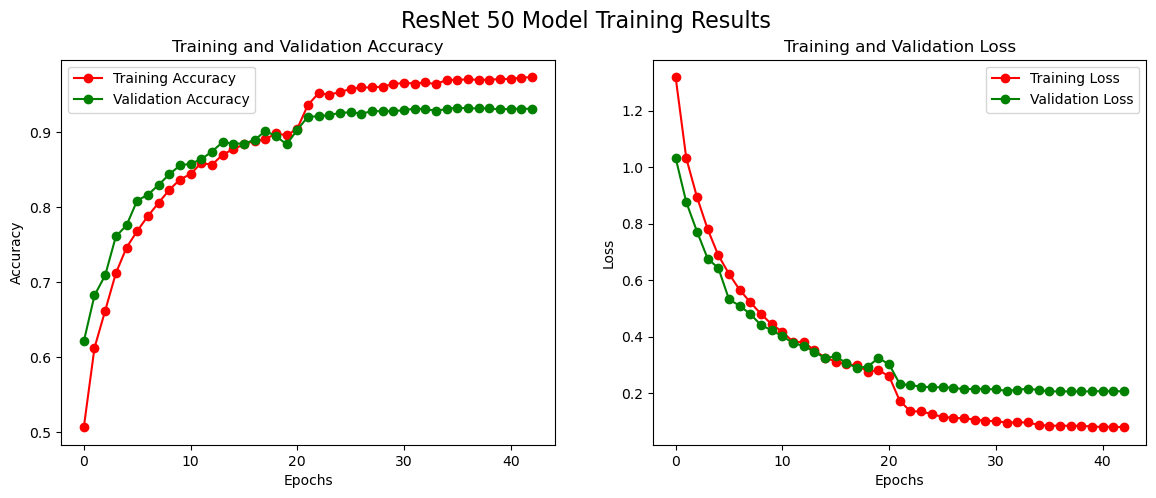

In [26]:
import matplotlib.pyplot as plt

# Assuming you have already trained your model and have the history object

accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(accuracy))

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Set the main title
fig.suptitle('ResNet 50 Model Training Results', fontsize=16)

# Plot Training and Validation Accuracy
ax1.plot(epochs, accuracy, 'ro-', label='Training Accuracy')
ax1.plot(epochs, val_accuracy, 'go-', label='Validation Accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Plot Training and Validation Loss
ax2.plot(epochs, loss, 'ro-', label='Training Loss')
ax2.plot(epochs, val_loss, 'go-', label='Validation Loss')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

# Show the plots
plt.show()


In [27]:
model.evaluate(X_test,y_test)

38/38 [==============================] - 2s 61ms/step - loss: 1.8025 - accuracy: 0.6864


[1.8024682998657227, 0.6864197254180908]

In [28]:
from tensorflow.keras.models import load_model

# Replace 'your_model_file.h5' with the actual file name
loaded_model_resnet = load_model('/kaggle/working/best_model_resnet.h5')


In [29]:
# Load the best model
best_model = tf.keras.models.load_model(os.path.join(best_model_dir, 'best_model_resnet.h5'))

# Evaluate the best model on the test set
test_loss, test_accuracy = best_model.evaluate(X_val, y_val)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

139/139 [==============================] - 9s 55ms/step - loss: 0.2058 - accuracy: 0.9317
Test Loss: 0.20583786070346832, Test Accuracy: 0.9316896796226501


In [30]:
y_pred=loaded_model_resnet.predict(X_val)
print(y_pred)

139/139 [==============================] - 8s 51ms/step
[[1.9422283e-05 3.4251898e-03 8.9295751e-01 6.5582979e-05 1.0317165e-01
  3.6072015e-04]
 [9.9999619e-01 1.8460783e-08 1.2728522e-08 4.8980904e-13 3.8347475e-06
  8.0326107e-11]
 [7.8085325e-09 9.9999249e-01 2.6464400e-11 3.1422328e-08 7.2980756e-06
  2.0385109e-07]
 ...
 [9.7553456e-01 8.4368803e-05 2.9362198e-07 3.4339857e-06 2.4377353e-02
  1.2893715e-08]
 [8.4705478e-09 4.8701689e-01 6.3208302e-07 4.7312431e-02 4.6538714e-01
  2.8289176e-04]
 [6.8973791e-06 2.0485634e-10 7.3625881e-05 1.6000170e-08 8.9317189e-05
  9.9983013e-01]]


In [31]:
import numpy as np
z=np.argmax(y_pred, axis=1) #return index of the large number 
z

array([2, 0, 1, ..., 0, 1, 5])

In [32]:
# Convert to integer labels
y_test_ = np.argmax(y_val, axis=1)

print(y_test_)

[2 0 1 ... 0 4 5]


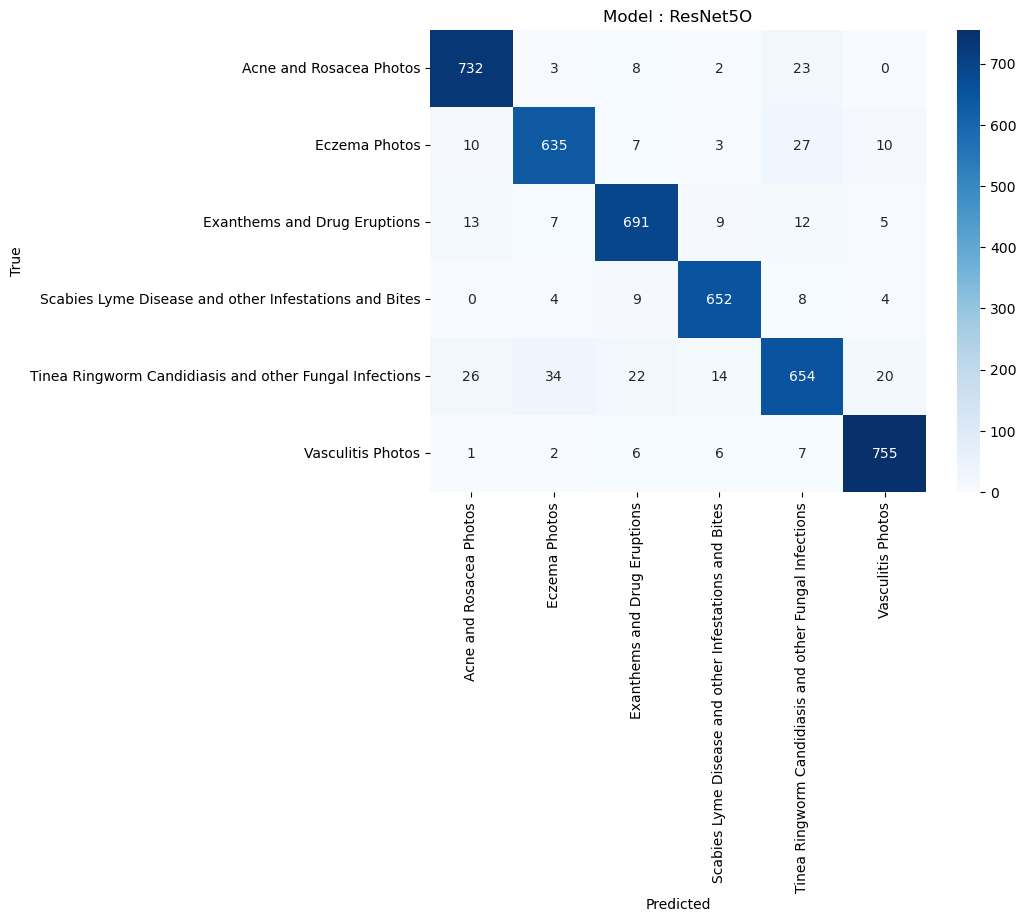

Classification Report:
                                                        precision    recall  f1-score   support

                               Acne and Rosacea Photos       0.94      0.95      0.94       768
                                         Eczema Photos       0.93      0.92      0.92       692
                          Exanthems and Drug Eruptions       0.93      0.94      0.93       737
 Scabies Lyme Disease and other Infestations and Bites       0.95      0.96      0.96       677
Tinea Ringworm Candidiasis and other Fungal Infections       0.89      0.85      0.87       770
                                     Vasculitis Photos       0.95      0.97      0.96       777

                                              accuracy                           0.93      4421
                                             macro avg       0.93      0.93      0.93      4421
                                          weighted avg       0.93      0.93      0.93      4421



In [38]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
conf_mat = confusion_matrix(y_test_, z)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Model : ResNet5O')
plt.show()

# Generate the classification report
report = classification_report(y_test_, z, target_names=class_names)
print("Classification Report:")
print(report)

In [39]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test_, z))

              precision    recall  f1-score   support

           0       0.94      0.95      0.94       768
           1       0.93      0.92      0.92       692
           2       0.93      0.94      0.93       737
           3       0.95      0.96      0.96       677
           4       0.89      0.85      0.87       770
           5       0.95      0.97      0.96       777

    accuracy                           0.93      4421
   macro avg       0.93      0.93      0.93      4421
weighted avg       0.93      0.93      0.93      4421



In [40]:
class_names=['Acne and Rosacea Photos','Eczema Photos','Exanthems and Drug Eruptions','Scabies Lyme Disease and other Infestations and Bites','Tinea Ringworm Candidiasis and other Fungal Infections','Vasculitis Photos']

In [44]:
# Step 2: Preprocess your input data (if needed)
def preprocess_input_image(image_path, target_size=(224, 224)):
    img = cv2.imread(image_path)
    img = cv2.resize(img, target_size)
    img = np.expand_dims(img, axis=0)  # Add an extra dimension for batch size
    return img

# Example usage of the preprocess_input_image function
#input_image_path = '/kaggle/input/balance-skin-data/train/Scabies Lyme Disease and other Infestations and Bites/biting-insects-16.jpg'
#input_image_path = '/kaggle/input/balance-skin-data/train/Vasculitis Photos/erythema-multiforme-113.jpg'
input_image_path = '/kaggle/input/balance-skin-data/test/Acne and Rosacea Photos/acne-cystic-61.jpg'
input_image = preprocess_input_image(input_image_path)

# Step 3: Use the predict method to obtain predictions
predictions = model.predict(input_image)

# The 'predictions' variable now contains the model's output. You can use it as needed.
print("Predictions:",predictions)
print("Predictions:",np.argmax(predictions)+1)
print(class_names[np.argmax(predictions)])

1/1 [==============================] - 0s 28ms/step
Predictions: [[1.0000000e+00 2.5191576e-13 3.3189629e-10 6.4904135e-09 9.5580792e-12
  2.8310259e-09]]
Predictions: 1
Acne and Rosacea Photos


# effecinet

In [30]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
import cv2
import tensorflow as tf
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tqdm import tqdm
import os
from sklearn.utils import shuffle
from sklearn.model_selection import train_test_split
from tensorflow.keras.applications import EfficientNetB0
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau, TensorBoard, ModelCheckpoint
from sklearn.metrics import classification_report,confusion_matrix
import ipywidgets as widgets
import io
from PIL import Image
from IPython.display import display,clear_output
from warnings import filterwarnings

In [43]:
effnet = EfficientNetB0(weights='imagenet',include_top=False,input_shape=(image_size,image_size,3))

16705208/16705208 [==============================] - 0s 0us/step


In [44]:
model = effnet.output
model = tf.keras.layers.GlobalAveragePooling2D()(model)
model = tf.keras.layers.Dropout(rate=0.5)(model)
model = tf.keras.layers.Dense(6,activation='softmax')(model)
model = tf.keras.models.Model(inputs=effnet.input, outputs = model)

In [46]:
import os
import tensorflow as tf
from tensorflow.keras.optimizers import Adam
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping, ModelCheckpoint

# Set parameters
EPOCHS = 30
BATCH_SIZE = 32
LEARNING_RATE = 0.001
BEST_MODEL_DIR = '/kaggle/working/'

# Create directory for saving the best model
os.makedirs(BEST_MODEL_DIR, exist_ok=True)

# Define the optimizer
optimizer = Adam(learning_rate=LEARNING_RATE)

# Compile the model
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])

# Define callbacks
callbacks = [
    ModelCheckpoint(
        os.path.join(BEST_MODEL_DIR, 'best_model_eff.h5'),
        monitor='val_loss', 
        save_best_only=True,
        mode='min', 
        verbose=1
    ),
    ReduceLROnPlateau(
        monitor='val_loss', 
        factor=0.1, 
        patience=3, 
        verbose=1, 
        mode='auto'
    ),
    EarlyStopping(
        monitor='val_loss', 
        patience=5
    )
]

# Train the model
history = model.fit(
    X_train, y_train, 
    validation_data=(X_val, y_val),
    epochs=EPOCHS, 
    batch_size=BATCH_SIZE,
    callbacks=callbacks
)


Epoch 1/30
543/543 [==============================] - ETA: 0s - loss: 0.9037 - accuracy: 0.6782
Epoch 1: val_loss improved from inf to 0.85958, saving model to /kaggle/working/best_model_eff.h5
543/543 [==============================] - 133s 225ms/step - loss: 0.9037 - accuracy: 0.6782 - val_loss: 0.8596 - val_accuracy: 0.7294 - lr: 0.0010
Epoch 2/30
543/543 [==============================] - ETA: 0s - loss: 0.4344 - accuracy: 0.8467
Epoch 2: val_loss improved from 0.85958 to 0.36804, saving model to /kaggle/working/best_model_eff.h5
543/543 [==============================] - 120s 221ms/step - loss: 0.4344 - accuracy: 0.8467 - val_loss: 0.3680 - val_accuracy: 0.8734 - lr: 0.0010
Epoch 3/30
543/543 [==============================] - ETA: 0s - loss: 0.2875 - accuracy: 0.9009
Epoch 3: val_loss improved from 0.36804 to 0.35303, saving model to /kaggle/working/best_model_eff.h5
543/543 [==============================] - 120s 221ms/step - loss: 0.2875 - accuracy: 0.9009 - val_loss: 0.3530 - 

In [47]:
model.save('best_model_eff.h5')

In [48]:
# Load the best model
best_model = tf.keras.models.load_model(os.path.join(best_model_dir, 'best_model_eff.h5'))

# Evaluate the best model on the test set
test_loss, test_accuracy = best_model.evaluate(X_val, y_val)
print(f"Test Loss: {test_loss}, Test Accuracy: {test_accuracy}")

136/136 [==============================] - 7s 39ms/step - loss: 0.0292 - accuracy: 0.9912
Test Loss: 0.029200419783592224, Test Accuracy: 0.9912402033805847


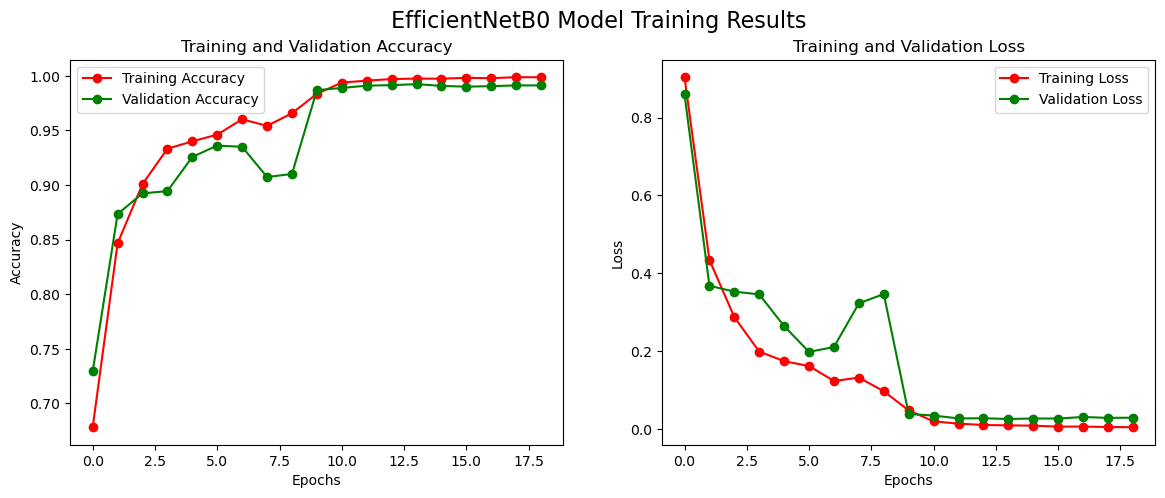

In [49]:
import matplotlib.pyplot as plt

# Assuming you have already trained your model and have the history object

accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(accuracy))

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Set the main title
fig.suptitle(' EfficientNetB0 Model Training Results', fontsize=16)

# Plot Training and Validation Accuracy
ax1.plot(epochs, accuracy, 'ro-', label='Training Accuracy')
ax1.plot(epochs, val_accuracy, 'go-', label='Validation Accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Plot Training and Validation Loss
ax2.plot(epochs, loss, 'ro-', label='Training Loss')
ax2.plot(epochs, val_loss, 'go-', label='Validation Loss')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

# Show the plots
plt.show()

In [51]:
class_names=['Acne and Rosacea Photos','Eczema Photos','Exanthems and Drug Eruptions','Scabies Lyme Disease and other Infestations and Bites','Tinea Ringworm Candidiasis and other Fungal Infections','Vasculitis Photos']

In [80]:
def preprocess_input_image(image_path, target_size=(224, 224)):
    img = cv2.imread(image_path)
    img = cv2.resize(img, target_size)
    img = np.expand_dims(img, axis=0)  # Add an extra dimension for batch size
    return img

# Example usage of the preprocess_input_image function
input_image_path = '/kaggle/input/dermnet/test/Tinea Ringworm Candidiasis and other Fungal Infections/candidiasis-vaginal-7.jpg'
#input_image_path = '/kaggle/input/balance-skin-data/train/Vasculitis Photos/erythema-multiforme-113.jpg'
#input_image_path = '/kaggle/input/balance-skin-data/train/Exanthems and Drug Eruptions/drug-eruptions-12.jpg'
input_image = preprocess_input_image(input_image_path)

# Step 3: Use the predict method to obtain predictions
predictions =best_model.predict(input_image)

# The 'predictions' variable now contains the model's output. You can use it as needed.
print("Predictions:",predictions)
print("Predictions:",np.argmax(predictions)+1)
print(class_names[np.argmax(predictions)])

1/1 [==============================] - 0s 34ms/step
Predictions: [[1.3311499e-03 1.7209504e-05 4.6436451e-04 1.7712279e-01 8.2105249e-01
  1.1906280e-05]]
Predictions: 5
Tinea Ringworm Candidiasis and other Fungal Infections


In [55]:
from tensorflow.keras.models import load_model

loaded_model_eff = load_model('/kaggle/working/best_model_eff.h5')


In [56]:
y_pred=loaded_model_eff.predict(X_val)
print(y_pred)
import numpy as np
z=np.argmax(y_pred, axis=1) #return index of the large number 
z

136/136 [==============================] - 6s 35ms/step
[[9.99996662e-01 1.52460800e-09 1.12069083e-08 1.16791909e-09
  3.33069693e-06 1.43593137e-10]
 [6.53884413e-08 1.30160736e-08 9.99994993e-01 9.30715505e-09
  4.92815479e-06 1.25900570e-08]
 [4.24334701e-08 9.87860280e-11 4.10779258e-11 1.21918529e-08
  4.35346408e-08 1.00000000e+00]
 ...
 [2.54844346e-09 7.28931707e-11 9.99999523e-01 8.84512852e-10
  3.11632562e-07 1.07591084e-07]
 [1.74411735e-03 1.56734110e-08 1.13117560e-04 1.56036791e-07
  9.98134434e-01 8.16336069e-06]
 [9.90880156e-10 1.75895076e-09 1.00000000e+00 2.54949950e-09
  4.17251904e-08 4.65482514e-12]]


array([0, 2, 5, ..., 2, 4, 2])

In [58]:
y_test = np.argmax(y_val, axis=1)

print(y_test)


[0 2 5 ... 2 4 2]


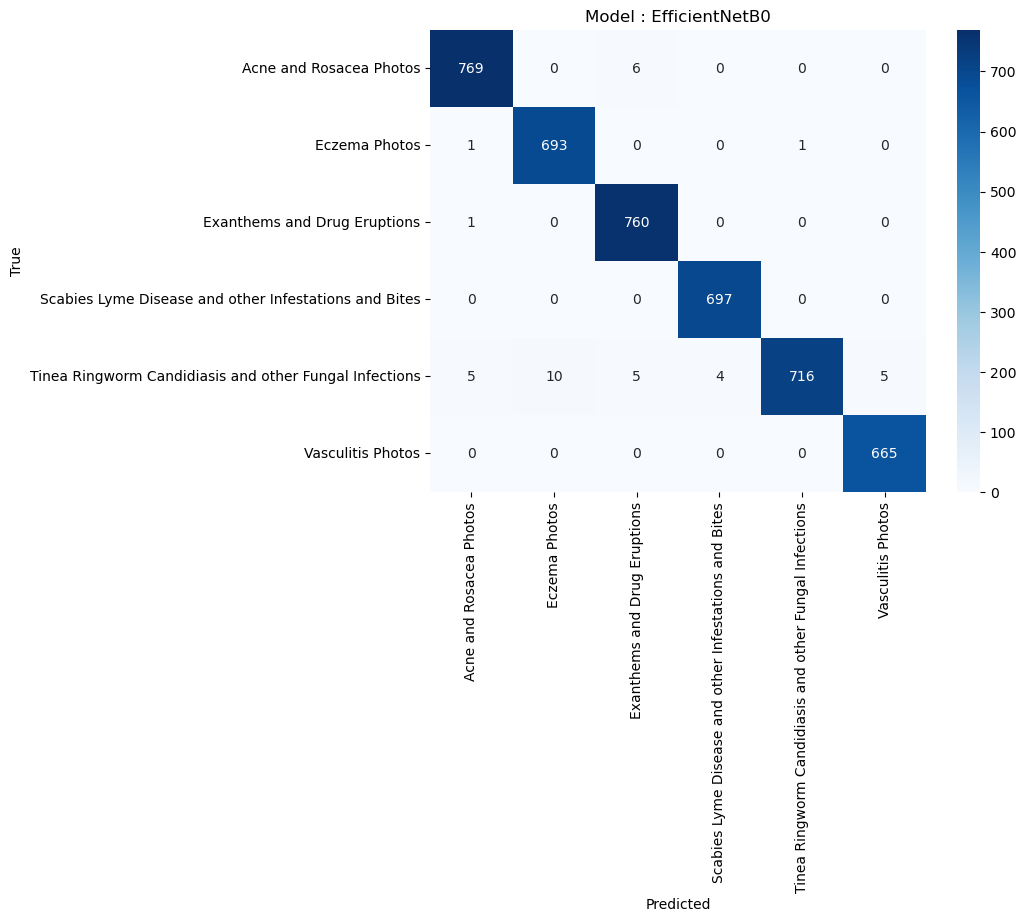

Classification Report:
                                                        precision    recall  f1-score   support

                               Acne and Rosacea Photos       0.99      0.99      0.99       775
                                         Eczema Photos       0.99      1.00      0.99       695
                          Exanthems and Drug Eruptions       0.99      1.00      0.99       761
 Scabies Lyme Disease and other Infestations and Bites       0.99      1.00      1.00       697
Tinea Ringworm Candidiasis and other Fungal Infections       1.00      0.96      0.98       745
                                     Vasculitis Photos       0.99      1.00      1.00       665

                                              accuracy                           0.99      4338
                                             macro avg       0.99      0.99      0.99      4338
                                          weighted avg       0.99      0.99      0.99      4338



In [60]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
conf_mat = confusion_matrix(y_test, z)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Model : EfficientNetB0')
plt.show()

# Generate the classification report
report = classification_report(y_test, z, target_names=class_names)
print("Classification Report:")
print(report)

In [61]:
from tensorflow.keras.utils import to_categorical
y_test = to_categorical(y_val, num_classes=6) 

136/136 [==============================] - 5s 36ms/step


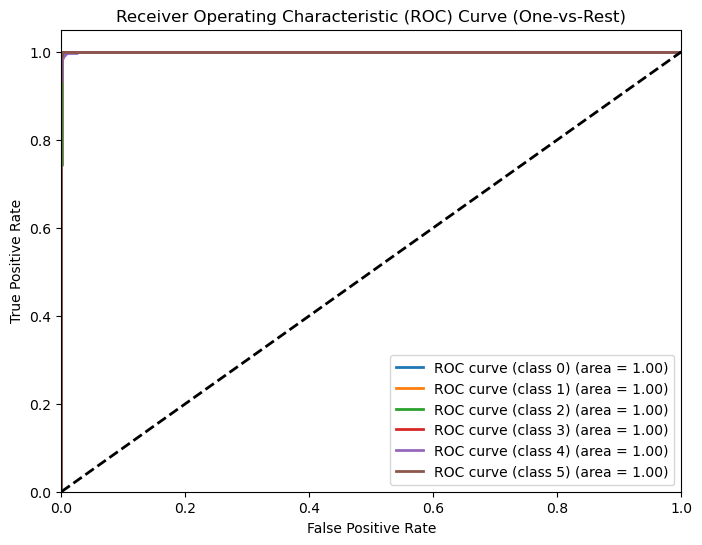

In [63]:
from sklearn.metrics import roc_curve,auc
y_pred_keras = model.predict(X_val.reshape(-1, 224, 224, 3))

fpr = dict()
tpr = dict()
roc_auc = dict()
for i in range(6):
    fpr[i], tpr[i], _ = roc_curve(y_val[:, i], y_pred_keras[:, i])
    roc_auc[i] = auc(fpr[i], tpr[i])


plt.figure(figsize=(8, 6))

for i in range(6):
    plt.plot(fpr[i], tpr[i], lw=2, label='ROC curve (class {0}) (area = {1:0.2f})'
             ''.format(i, roc_auc[i]))

plt.plot([0, 1], [0, 1], 'k--', lw=2)
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Receiver Operating Characteristic (ROC) Curve (One-vs-Rest)')
plt.legend(loc="lower right")
plt.show()

In [64]:
from tensorflow import keras
from tensorflow_hub import KerasLayer  # or wherever your custom object is from

with keras.utils.custom_object_scope({'KerasLayer': KerasLayer}):
    model = keras.models.load_model('/kaggle/working/best_model_eff.h5')

# Convert the Keras model to TensorFlow Lite format (.tflite)
converter = tf.lite.TFLiteConverter.from_keras_model(model)
tflite_model = converter.convert()

# Save the TensorFlow Lite model to a file
with open('best_model_eff.tflite', 'wb') as f:
    f.write(tflite_model)

# mobilenet

In [65]:
import os
import cv2
import numpy as np
from sklearn.model_selection import train_test_split
from keras.applications import MobileNet
from keras.models import Sequential
from keras.layers import GlobalAveragePooling2D, Dense
from matplotlib import pyplot as plt
from tensorflow.keras.optimizers import Adam

In [66]:
base_model = MobileNet(weights='imagenet', include_top=False, input_shape=(224, 224, 3))

17225924/17225924 [==============================] - 0s 0us/step


In [67]:
model = Sequential()
model.add(base_model)
model.add(GlobalAveragePooling2D())
model.add(Dense(64, activation='relu'))
model.add(Dense(128, activation='relu'))
model.add(Dropout(0.5))
model.add(Dense(6, activation='softmax'))

optimizer = tf.keras.optimizers.Adam(learning_rate = 0.001)
model.compile(optimizer=optimizer, loss='categorical_crossentropy', metrics=['accuracy'])
from tensorflow.keras.callbacks import ReduceLROnPlateau, EarlyStopping
EPOCHS = 65
BATCH_SIZE = 32
best_model_dir = '/kaggle/working/'

os.makedirs(best_model_dir, exist_ok=True)

model_checkpoint = ModelCheckpoint(
    os.path.join(best_model_dir, 'best_model_mobile.h5'),
    monitor='val_loss', 
    save_best_only=True,
    mode='min', 
    verbose=1
)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.1, patience=3, 
                              verbose=1, mode='auto')

early_stopping = tf.keras.callbacks.EarlyStopping(monitor='val_loss', patience=10)
history = model.fit(X_train,y_train, validation_data=(X_val, y_val),
                   epochs = EPOCHS, batch_size=BATCH_SIZE,callbacks=[model_checkpoint ,early_stopping,reduce_lr])


Epoch 1/65
543/543 [==============================] - ETA: 0s - loss: 1.4083 - accuracy: 0.4637
Epoch 1: val_loss improved from inf to 1.18835, saving model to /kaggle/working/best_model_mobile.h5
543/543 [==============================] - 87s 154ms/step - loss: 1.4083 - accuracy: 0.4637 - val_loss: 1.1883 - val_accuracy: 0.5546 - lr: 0.0010
Epoch 2/65
542/543 [============================>.] - ETA: 0s - loss: 1.0225 - accuracy: 0.6360
Epoch 2: val_loss improved from 1.18835 to 1.00008, saving model to /kaggle/working/best_model_mobile.h5
543/543 [==============================] - 82s 150ms/step - loss: 1.0225 - accuracy: 0.6359 - val_loss: 1.0001 - val_accuracy: 0.6339 - lr: 0.0010
Epoch 3/65
542/543 [============================>.] - ETA: 0s - loss: 0.7970 - accuracy: 0.7241
Epoch 3: val_loss did not improve from 1.00008
543/543 [==============================] - 81s 149ms/step - loss: 0.7970 - accuracy: 0.7241 - val_loss: 1.0634 - val_accuracy: 0.6325 - lr: 0.0010
Epoch 4/65
542/543

In [68]:
from tensorflow.keras.models import load_model

loaded_model_mobile = load_model('/kaggle/working/best_model_mobile.h5')


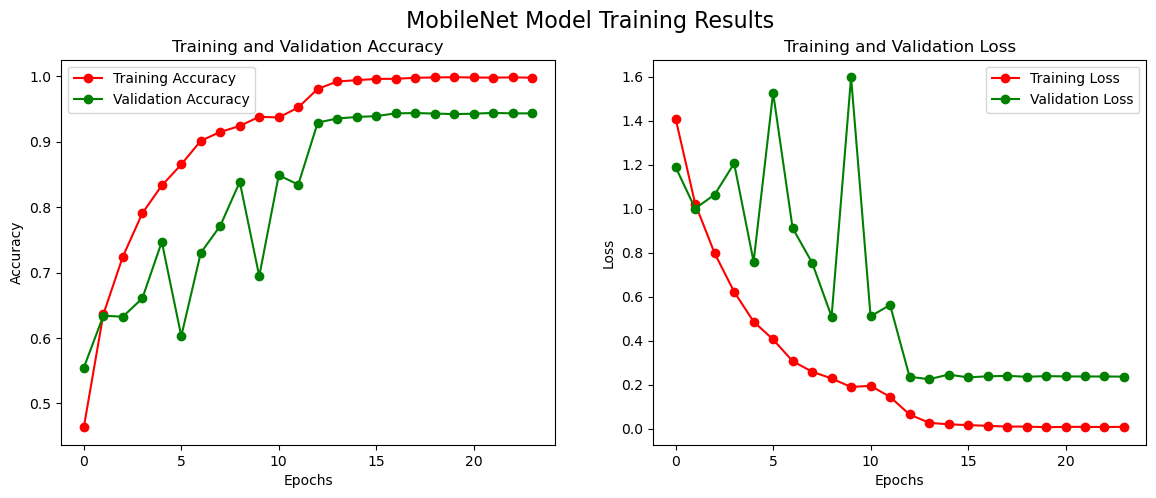

In [69]:
import matplotlib.pyplot as plt

# Assuming you have already trained your model and have the history object

accuracy = history.history['accuracy']
val_accuracy = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs = range(len(accuracy))

# Create subplots
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

# Set the main title
fig.suptitle(' MobileNet Model Training Results', fontsize=16)

# Plot Training and Validation Accuracy
ax1.plot(epochs, accuracy, 'ro-', label='Training Accuracy')
ax1.plot(epochs, val_accuracy, 'go-', label='Validation Accuracy')
ax1.set_title('Training and Validation Accuracy')
ax1.set_xlabel('Epochs')
ax1.set_ylabel('Accuracy')
ax1.legend()

# Plot Training and Validation Loss
ax2.plot(epochs, loss, 'ro-', label='Training Loss')
ax2.plot(epochs, val_loss, 'go-', label='Validation Loss')
ax2.set_title('Training and Validation Loss')
ax2.set_xlabel('Epochs')
ax2.set_ylabel('Loss')
ax2.legend()

# Show the plots
plt.show()

In [70]:
model.evaluate(X_val,y_val)

136/136 [==============================] - 3s 24ms/step - loss: 0.2363 - accuracy: 0.9431


[0.23625065386295319, 0.9430612921714783]

In [71]:
y_pred=loaded_model_mobile.predict(X_val)
print(y_pred)
import numpy as np
z=np.argmax(y_pred, axis=1) #return index of the large number 
z

136/136 [==============================] - 3s 21ms/step
[[9.9997640e-01 4.6220288e-07 4.7784948e-07 4.5741965e-07 2.1638753e-05
  5.7717807e-07]
 [1.2768370e-09 1.4466611e-05 9.9997139e-01 9.2057597e-08 2.9441651e-06
  1.1137685e-05]
 [7.9829508e-05 8.3508872e-04 1.9176365e-04 2.5427921e-04 6.5695904e-03
  9.9206948e-01]
 ...
 [3.5818946e-09 1.0467142e-05 9.9995840e-01 9.6247838e-08 3.0860141e-05
  1.3519251e-07]
 [1.7067580e-01 3.5147590e-03 1.2491861e-03 3.9056672e-03 8.1944305e-01
  1.2116046e-03]
 [1.0248495e-11 1.0294963e-08 1.0000000e+00 2.6168565e-10 6.9335373e-09
  1.3037003e-09]]


array([0, 2, 5, ..., 2, 4, 2])

In [72]:
y_test = np.argmax(y_val, axis=1)

print(y_test)


[0 2 5 ... 2 4 2]


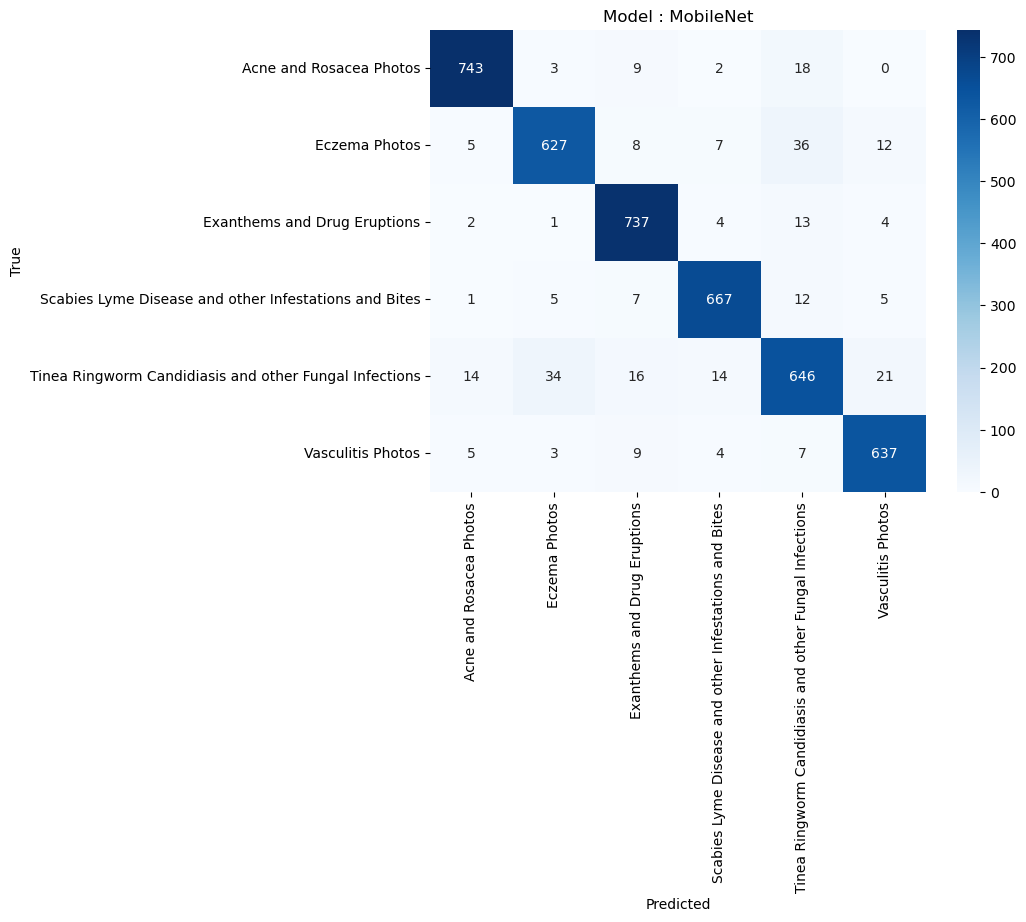

Classification Report:
                                                        precision    recall  f1-score   support

                               Acne and Rosacea Photos       0.96      0.96      0.96       775
                                         Eczema Photos       0.93      0.90      0.92       695
                          Exanthems and Drug Eruptions       0.94      0.97      0.95       761
 Scabies Lyme Disease and other Infestations and Bites       0.96      0.96      0.96       697
Tinea Ringworm Candidiasis and other Fungal Infections       0.88      0.87      0.87       745
                                     Vasculitis Photos       0.94      0.96      0.95       665

                                              accuracy                           0.94      4338
                                             macro avg       0.94      0.94      0.94      4338
                                          weighted avg       0.94      0.94      0.94      4338



In [73]:
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import matplotlib.pyplot as plt

# Generate the confusion matrix
conf_mat = confusion_matrix(y_test, z)

# Create a heatmap for the confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(conf_mat, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.xlabel('Predicted')
plt.ylabel('True')
plt.title('Model : MobileNet')
plt.show()

# Generate the classification report
report = classification_report(y_test, z, target_names=class_names)
print("Classification Report:")
print(report)

In [77]:
from sklearn.metrics import classification_report,confusion_matrix
print(classification_report(y_test, z))

              precision    recall  f1-score   support

           0       0.96      0.96      0.96       775
           1       0.93      0.90      0.92       695
           2       0.94      0.97      0.95       761
           3       0.96      0.96      0.96       697
           4       0.88      0.87      0.87       745
           5       0.94      0.96      0.95       665

    accuracy                           0.94      4338
   macro avg       0.94      0.94      0.94      4338
weighted avg       0.94      0.94      0.94      4338



In [78]:
def preprocess_input_image(image_path, target_size=(224, 224)):
    img = cv2.imread(image_path)
    img = cv2.resize(img, target_size)
    img = np.expand_dims(img, axis=0)  # Add an extra dimension for batch size
    return img

# Example usage of the preprocess_input_image function
input_image_path = '/kaggle/input/dermnet/test/Tinea Ringworm Candidiasis and other Fungal Infections/tinea-versicolor-94.jpg'
#input_image_path = '/kaggle/input/balance-skin-data/train/Vasculitis Photos/erythema-multiforme-113.jpg'
#input_image_path = '/kaggle/input/balance-skin-data/train/Exanthems and Drug Eruptions/drug-eruptions-12.jpg'
input_image = preprocess_input_image(input_image_path)

# Step 3: Use the predict method to obtain predictions
predictions = model.predict(input_image)

# The 'predictions' variable now contains the model's output. You can use it as needed.
print("Predictions:",predictions)
print("Predictions:",np.argmax(predictions)+1)
print(class_names[np.argmax(predictions)])

1/1 [==============================] - 1s 594ms/step
Predictions: [[3.3245201e-04 2.4900498e-02 3.9036268e-01 2.5410636e-04 5.8331770e-01
  8.3259615e-04]]
Predictions: 5
Tinea Ringworm Candidiasis and other Fungal Infections


In [84]:
pip install pydot graphviz


Note: you may need to restart the kernel to use updated packages.


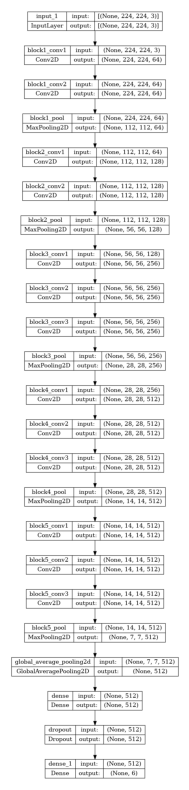

In [86]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import os
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt

best_model_vgg = tf.keras.models.load_model(os.path.join(best_model_dir, 'best_model_vgg.h5'))
# Plot the model architecture
plot_model(best_model_vgg, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

# Display the model architecture
img = plt.imread('model_architecture.png')
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.show()


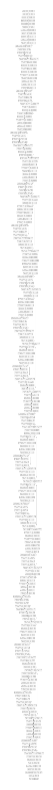

In [87]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import os
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt

best_model_Eff = tf.keras.models.load_model(os.path.join(best_model_dir, '/kaggle/working/best_model_eff.h5'))
# Plot the model architecture
plot_model(best_model_Eff, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

# Display the model architecture
img = plt.imread('model_architecture.png')
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.show()

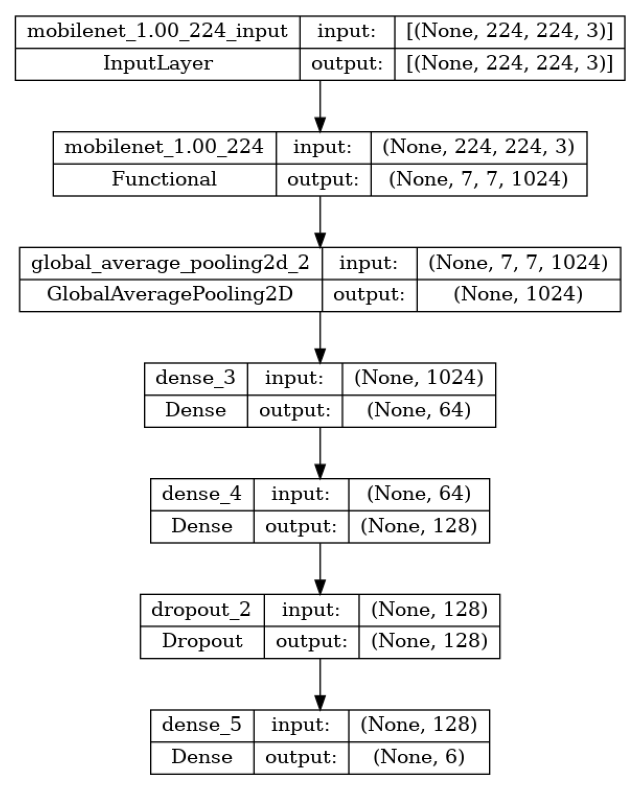

In [88]:
import tensorflow as tf
from tensorflow.keras.applications import VGG16
from tensorflow.keras.models import Model
from tensorflow.keras.layers import GlobalAveragePooling2D, Dense
from tensorflow.keras.callbacks import ModelCheckpoint, ReduceLROnPlateau, EarlyStopping
import os
from tensorflow.keras.utils import plot_model
import matplotlib.pyplot as plt

best_model_mobile = tf.keras.models.load_model(os.path.join(best_model_dir, '/kaggle/working/best_model_mobile.h5'))
# Plot the model architecture
plot_model(best_model_mobile, to_file='model_architecture.png', show_shapes=True, show_layer_names=True)

# Display the model architecture
img = plt.imread('model_architecture.png')
plt.figure(figsize=(10, 10))
plt.imshow(img)
plt.axis('off')
plt.show()